# Risk assessment for river flooding — Kazakhstan

Adapted from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and
[FLOODS](https://github.com/CLIMAAX/FLOODS) GitHub repository for Kazakhstan.

## Data Substitutions

| Original (CLIMAAX / Europe) | Kazakhstan Replacement | Reason |
|---|---|---|
| LUISA land use map (EU-only, 100m, EPSG:3035) | ESA WorldCover 2021 v2.0 (global, 10m→100m, EPSG:4326) | LUISA covers only Europe |
| LUISA class codes (1111, 1121 …) | ESA WorldCover class codes (10, 40, 50 …) | Class system tied to dataset |
| JRC EU depth-damage curves | Huizinga et al. 2017 global depth-damage curves | EU curves not valid outside Europe; Huizinga provides Central Asia values |
| Max damage in €/m² (EU GDP-adjusted Excel) | Max damage in USD/m² from Huizinga 2017 (Kazakhstan region) | USD values published for Central Asia region |
| DamageScanner library | Direct numpy raster calculation | DamageScanner requires osgeo/GDAL which is unavailable |
| EPSG:3035 projected CRS | EPSG:4326 geographic CRS | EPSG:3035 is Europe-only |
| Pixel area = 100m × 100m exactly | Pixel area approximated as 100m × 100m (accepted limitation) | At 45°N true E-W pixel ≈ 70m; ~30% area underestimate noted |

**Reference:** Huizinga J., de Moel H., Szewczyk W. (2017). Global flood depth-damage
functions. JRC Technical Report EUR 28552 EN.
https://publications.jrc.ec.europa.eu/repository/handle/JRC105688

## Setup — libraries

In [1]:
import re
import math
import logging
from pathlib import Path

import pooch
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from rioxarray.merge import merge_arrays
import xarray as xr
import rasterio
from rasterio.windows import from_bounds as rio_from_bounds
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as ctx

logging.getLogger('pooch').setLevel(logging.WARNING)

## Setup — region

In [2]:
SHAPEFILE_PATH = Path(
    r'C:\Users\dauzo\Models\crabook-kazakhstan\crabook'
    r'\KAZ_BORDER_VERSION_1\LVL3\SHP_LVL3\KAZ_OSM_BORDER_LVL3.shp'
)
OBLAST_FIELD = 'oblast_en'

kaz = gpd.read_file(SHAPEFILE_PATH)

selected_oblast = 'North Kazakhstan Region' 

if selected_oblast is not None:
    region_gdf  = kaz[kaz[OBLAST_FIELD] == selected_oblast].dissolve()
    region_name = re.sub(r'[^a-zA-Z0-9]', '', selected_oblast)
    region_id   = selected_oblast
else:
    region_gdf  = gpd.GeoDataFrame(geometry=[kaz.geometry.unary_union], crs=kaz.crs)
    region_name = 'Kazakhstan'
    region_id   = 'KAZ'

coords_user = gpd.GeoSeries.get_coordinates(region_gdf).to_numpy()
bbox = [
    float(coords_user[:,0].min()),
    float(coords_user[:,1].min()),
    float(coords_user[:,0].max()),
    float(coords_user[:,1].max()),
]
print(f'Region : {region_id}')
print(f'Bbox   : {bbox}')

Region : North Kazakhstan Region
Bbox   : [65.96311469999995, 52.20696040000013, 74.03496069999994, 55.44217009999994]


## Setup — directory structure

In [3]:
hazard_folder    = Path('.')                    
hazard_data_dir  = hazard_folder / f'data_{region_name}'

workflow_folder  = Path('.') / 'FLOOD_RIVER_risk'
data_general_dir = workflow_folder / 'general_data'
data_dir         = workflow_folder / f'data_{region_name}'
results_dir      = workflow_folder / f'results_{region_name}'
plot_dir         = workflow_folder / f'plots_{region_name}'

for d in [data_general_dir, data_dir, results_dir, plot_dir]:
    d.mkdir(parents=True, exist_ok=True)

## 1 — Hazard: load flood maps from hazard notebook

In [4]:
floodmaps_path = hazard_data_dir / f'floodmaps_all_GLOFAS_PresentScenario_{region_name}.nc'
floodmaps = xr.open_dataset(floodmaps_path)
rps = list(floodmaps.data_vars)
print(f'Loaded flood maps: {rps}')

Loaded flood maps: ['RP10', 'RP50', 'RP100', 'RP200', 'RP500']


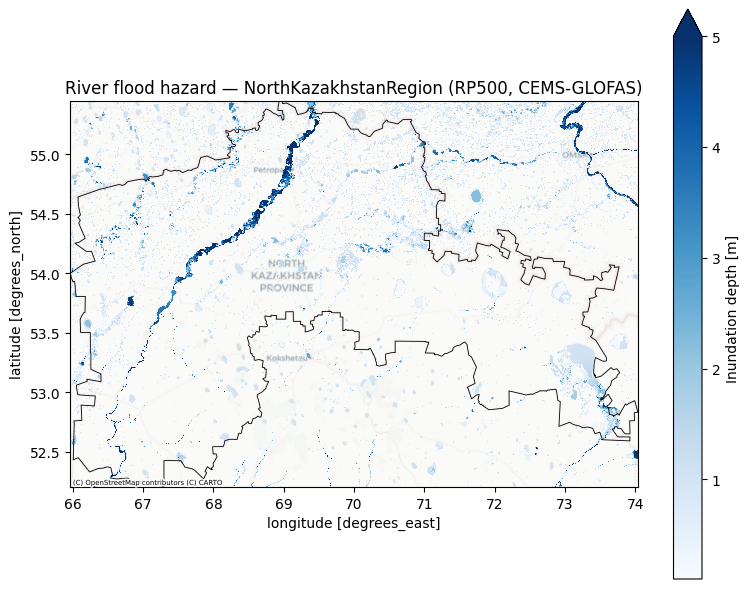

In [5]:
step = max(1, int(500 / 90))

fig, ax = plt.subplots(figsize=(8, 6))
floodmaps['RP500'].isel(x=slice(None,None,step), y=slice(None,None,step)).plot(
    ax=ax, cmap='Blues', vmax=5,
    cbar_kwargs={'label': 'Inundation depth [m]'},
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
ctx.add_basemap(ax=ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=5)
ax.set_title(f'River flood hazard — {region_name} (RP500, CEMS-GLOFAS)')
plt.tight_layout()
fig.savefig(plot_dir / f'Floodmap_RP500_{region_name}.png', dpi=150)
plt.show()

## 2 — Load Aqueduct future scenario maps

In [6]:
return_period_aq  = 250
data_dir_aqueduct = hazard_data_dir / 'aqueduct_floods'

aq_base = xr.open_dataset(
    data_dir_aqueduct / f'inunriver_historical_000000000WATCH_1980_rp{return_period_aq:05}_{region_name}.nc'
)
aq_all = xr.open_dataset(
    data_dir_aqueduct / f'inunriver_AllScenarios_AllModels_AllYears_rp{return_period_aq:05}_{region_name}.nc'
)
print('Aqueduct datasets loaded.')

Aqueduct datasets loaded.


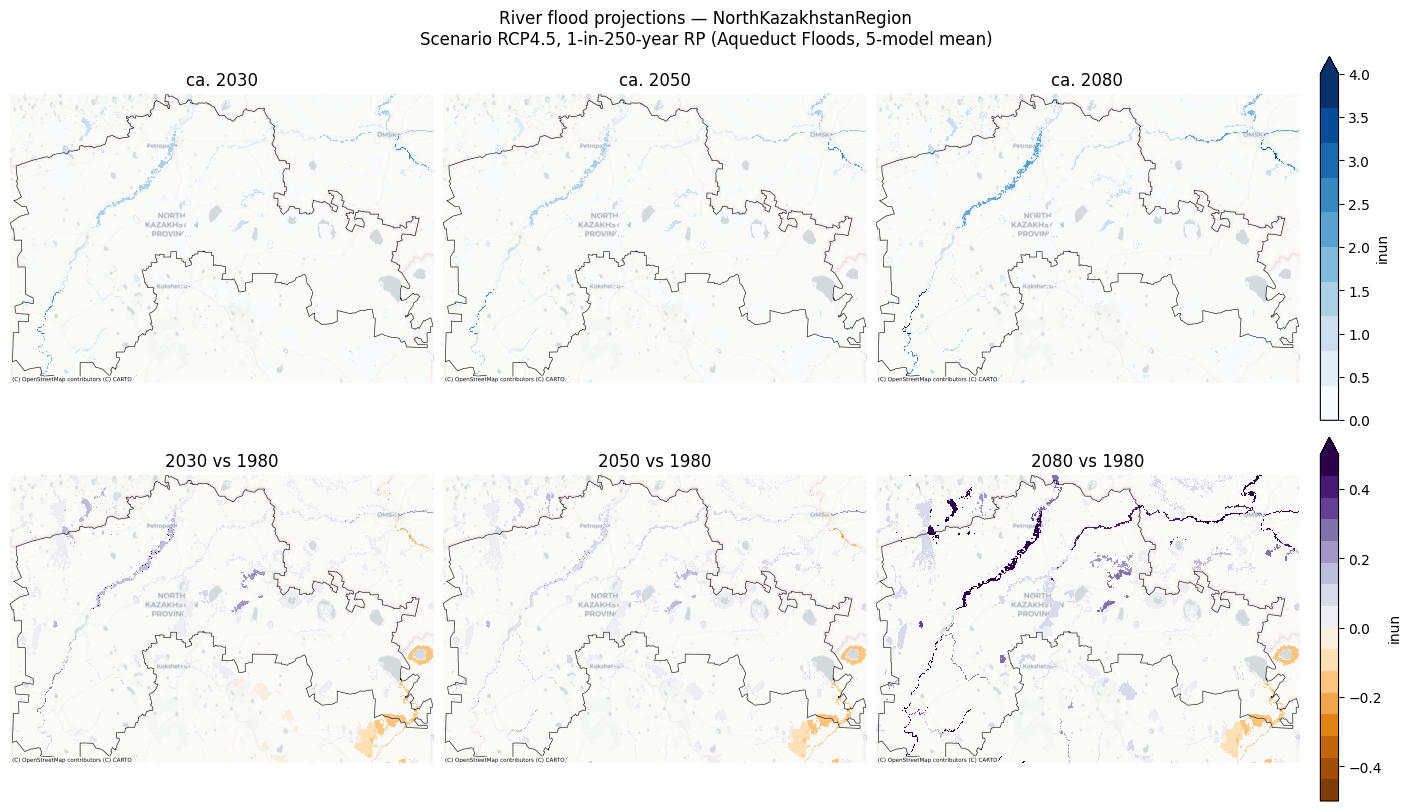

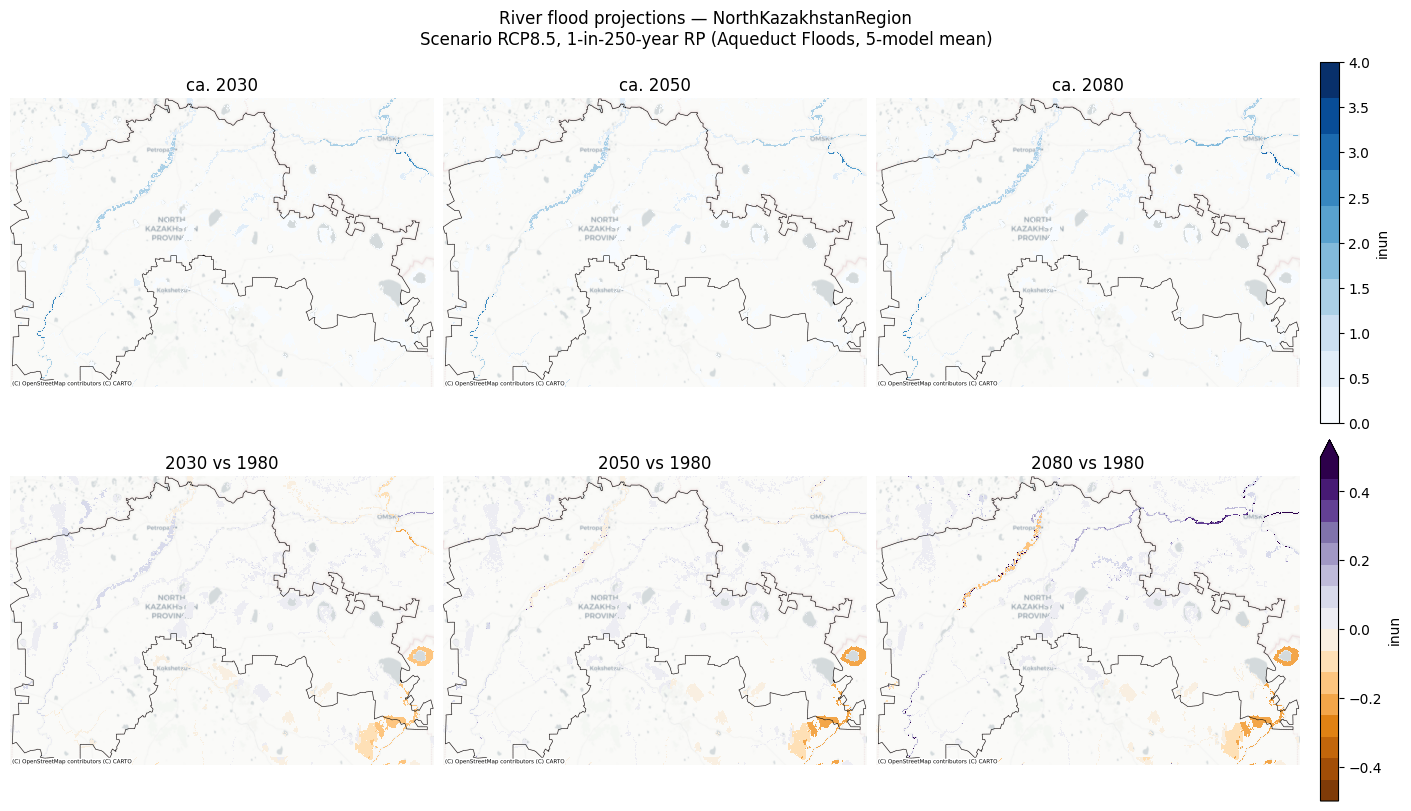

In [7]:
cmap_flood = plt.get_cmap('Blues', 10)
cmap_diff  = plt.get_cmap('PuOr', 16)
scenarios  = ['rcp4p5', 'rcp8p5']
years      = [2030, 2050, 2080]

for scenario in scenarios:
    fig, axs = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True, constrained_layout=True)
    scen_label = scenario.upper().replace('P5', '.5')
    fig.suptitle(
        f'River flood projections — {region_name}\n'
        f'Scenario {scen_label}, 1-in-{return_period_aq}-year RP (Aqueduct Floods, 5-model mean)',
        fontsize=12,
    )
    vmax_abs = float(np.ceil(float(aq_all['inun'].sel(year=years[-1], scenario=scenarios[-1]).max())))

    for jj, year in enumerate(years):
        da_abs  = aq_all['inun'].sel(year=year, scenario=scenario)
        da_diff = da_abs - aq_base['inun'].squeeze()
        last    = (jj == len(years) - 1)

        _ckw1 = {'label': 'Inundation depth [m]'} if last else {}
        da_abs.plot(ax=axs[0,jj], cmap=cmap_flood, vmin=0, vmax=vmax_abs,
                    add_colorbar=last, **_ckw1)
        region_gdf.boundary.plot(ax=axs[0,jj], color='black', linewidth=0.4)
        ctx.add_basemap(axs[0,jj], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
        axs[0,jj].set_title(f'ca. {year}')
        axs[0,jj].set_axis_off()

        _ckw2 = {'label': 'Depth change vs 1980 [m]'} if last else {}
        da_diff.plot(ax=axs[1,jj], cmap=cmap_diff, vmin=-0.5, vmax=0.5,
                     add_colorbar=last, **_ckw2)
        region_gdf.boundary.plot(ax=axs[1,jj], color='black', linewidth=0.4)
        ctx.add_basemap(axs[1,jj], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
        axs[1,jj].set_title(f'{year} vs 1980')
        axs[1,jj].set_axis_off()

    fig.savefig(plot_dir / f'Aqueduct_{region_name}_{scen_label.replace(".","")}.png', dpi=150)
    plt.show()

## 3 — Exposure: ESA WorldCover 2021

**Substitution:** LUISA (EU-only, EPSG:3035) → ESA WorldCover 2021 v2.0 (global, 10m).
Tiles are 3°×3°, hosted on a public AWS S3 bucket — no registration required.
We clip and resample to ~100m during reading to avoid loading full 10m tiles into memory.

In [8]:
ESA_WC_BASE = 'https://esa-worldcover.s3.amazonaws.com/v200/2021/map'

def esa_wc_tiles_for_bbox(bbox):
    """ESA WorldCover tiles are 3°×3°, named by SW corner e.g. N42E075."""
    lon_min, lat_min, lon_max, lat_max = bbox
    tiles = []
    for lat in range(int(math.floor(lat_min/3))*3, int(math.ceil(lat_max/3))*3, 3):
        for lon in range(int(math.floor(lon_min/3))*3, int(math.ceil(lon_max/3))*3, 3):
            ns = f'N{lat:02d}' if lat >= 0 else f'S{abs(lat):02d}'
            ew = f'E{lon:03d}' if lon >= 0 else f'W{abs(lon):03d}'
            tiles.append(f'{ns}{ew}')
    return tiles

def download_esa_wc_tile(tile_name, dest_folder):
    fname    = f'ESA_WorldCover_10m_2021_v200_{tile_name}_Map.tif'
    out_path = dest_folder / fname
    if out_path.exists():
        print(f'  Cached: {fname}')
    else:
        url = f'{ESA_WC_BASE}/{fname}'
        pooch.retrieve(url=url, known_hash=None, path=dest_folder, fname=fname)
        print(f'  Downloaded: {fname}')
    return out_path

esa_wc_dir       = data_general_dir / 'esa_wc_tiles'
esa_wc_dir.mkdir(exist_ok=True)
esa_wc_tile_names = esa_wc_tiles_for_bbox(bbox)
print(f'ESA WorldCover tiles needed: {esa_wc_tile_names}')
esa_wc_tile_paths = [download_esa_wc_tile(t, esa_wc_dir) for t in esa_wc_tile_names]

ESA WorldCover tiles needed: ['N51E063', 'N51E066', 'N51E069', 'N51E072', 'N54E063', 'N54E066', 'N54E069', 'N54E072']
  Cached: ESA_WorldCover_10m_2021_v200_N51E063_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E066_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E069_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E072_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E063_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E066_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E069_Map.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E072_Map.tif


In [9]:
TARGET_RES_DEG = 100 / 111320  

clipped_paths = []
for p in esa_wc_tile_paths:
    out_path = esa_wc_dir / p.name.replace('.tif', '_clipped100m.tif')
    if out_path.exists():
        print(f'  Cached: {out_path.name}')
    else:
        with rasterio.open(p) as src:
            tb = src.bounds
            x0 = max(tb.left,   bbox[0])
            y0 = max(tb.bottom, bbox[1])
            x1 = min(tb.right,  bbox[2])
            y1 = min(tb.top,    bbox[3])

            inter_h = max(1, int((y1 - y0) / TARGET_RES_DEG))
            inter_w = max(1, int((x1 - x0) / TARGET_RES_DEG))

            win = rio_from_bounds(x0, y0, x1, y1, src.transform)
            data = src.read(
                1,
                window=win,
                out_shape=(inter_h, inter_w),
                resampling=Resampling.nearest,
            )
            out_transform = rasterio.transform.from_bounds(
                x0, y0, x1, y1, inter_w, inter_h
            )
            with rasterio.open(
                out_path, 'w', driver='GTiff',
                height=inter_h, width=inter_w, count=1,
                dtype=data.dtype, crs=src.crs, transform=out_transform,
            ) as dst:
                dst.write(data, 1)
        print(f'  Saved 100m: {out_path.name}  shape: {data.shape}')
    clipped_paths.append(out_path)

  Cached: ESA_WorldCover_10m_2021_v200_N51E063_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E066_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E069_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N51E072_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E063_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E066_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E069_Map_clipped100m.tif
  Cached: ESA_WorldCover_10m_2021_v200_N54E072_Map_clipped100m.tif


In [10]:
if not clipped_paths:
    clipped_paths = list(esa_wc_dir.glob('*_clipped100m.tif'))
    print(f'Rebuilt from disk: {len(clipped_paths)} tiles')

esa_wc_arrays = [rxr.open_rasterio(p, masked=True) for p in clipped_paths]
esa_wc_local  = merge_arrays(esa_wc_arrays).squeeze() if len(esa_wc_arrays) > 1 else esa_wc_arrays[0].squeeze()
esa_wc_local.rio.write_crs('EPSG:4326', inplace=True)
print(f'ESA WC shape: {esa_wc_local.shape}  resolution: {esa_wc_local.rio.resolution()}')

ESA WC shape: (3601, 8972)  resolution: (0.0008996414634157901, -0.0008983164328656668)


In [11]:
landcover_path = data_dir / f'land_cover_ESA_WC_{region_name}.tif'
esa_wc_local.rio.to_raster(landcover_path)
print(f'Saved: {landcover_path.name}')

Saved: land_cover_ESA_WC_NorthKazakhstanRegion.tif


c:\Users\dauzo\miniconda3\envs\crabook-kz\Lib\site-packages\IPython\core\interactiveshell.py:3178: SerializationWarning: saving variable None with floating point data as an integer dtype without any _FillValue to use for NaNs
  result = runner(coro)


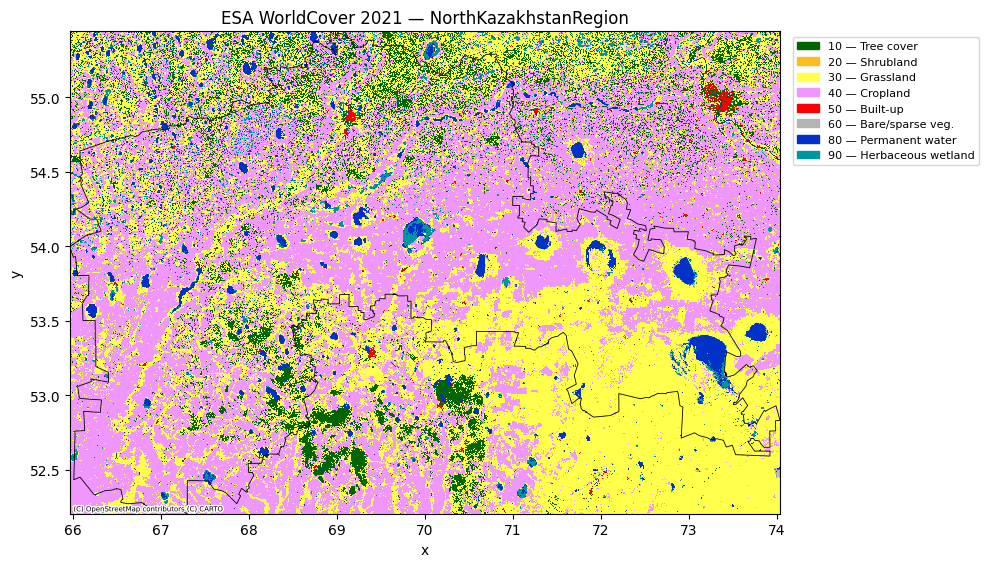

In [12]:
ESA_WC_LABELS = {
    10:  ('Tree cover',           '#006400'),
    20:  ('Shrubland',            '#ffbb22'),
    30:  ('Grassland',            '#ffff4c'),
    40:  ('Cropland',             '#f096ff'),
    50:  ('Built-up',             '#fa0000'),
    60:  ('Bare/sparse veg.',     '#b4b4b4'),
    70:  ('Snow and ice',         '#f0f0f0'),
    80:  ('Permanent water',      '#0032c8'),
    90:  ('Herbaceous wetland',   '#0096a0'),
    95:  ('Mangroves',            '#00cf75'),
    100: ('Moss and lichen',      '#fae6a0'),
}

lc_vals         = esa_wc_local.values
present_classes = sorted(set(int(v) for v in lc_vals[~np.isnan(lc_vals)]) & ESA_WC_LABELS.keys())

cmap_lc = mcolors.ListedColormap([ESA_WC_LABELS[c][1] for c in present_classes])
bounds  = present_classes + [present_classes[-1] + 1]
norm_lc = mcolors.BoundaryNorm(bounds, cmap_lc.N)

fig, ax = plt.subplots(figsize=(10, 8))
esa_wc_local.isel(x=slice(None,None,3), y=slice(None,None,3)).plot(
    ax=ax, cmap=cmap_lc, norm=norm_lc, add_colorbar=False,
)
region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.6)
ctx.add_basemap(ax=ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=5)
legend_patches = [
    plt.matplotlib.patches.Patch(color=ESA_WC_LABELS[c][1], label=f'{c} — {ESA_WC_LABELS[c][0]}')
    for c in present_classes
]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title(f'ESA WorldCover 2021 — {region_name}')
plt.tight_layout()
fig.savefig(plot_dir / f'LandCover_ESA_WC_{region_name}.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Vulnerability: Huizinga et al. 2017 global depth-damage curves

**Substitution:** JRC EU curves → Huizinga (2017) global curves.

Original does not have forest and grassland while ESA doesn't have industrial and transport.

Maximum damage values [USD/m²] (Huizinga 2017 approximate for Asia):
- Residential: $435/m²  |  Commercial: $629/m²
- Built-up class 50: weighted 70% residential + 30% commercial = $493.2/m²
- Cropland / agriculture: $0.3/m²
- Forest / shrubland: $2/m²

In [13]:
depths      = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0])
residential = np.array([0.00, 0.33, 0.49, 0.62, 0.72, 0.87, 0.93, 0.98, 1.00])
commercial  = np.array([0.00, 0.38, 0.54, 0.66, 0.76, 0.88, 0.94, 0.98, 1.00])
agriculture = np.array([0.00, 0.14, 0.37, 0.52, 0.56, 0.66, 0.83, 0.99, 1.00])
forest_curve= np.array([0.00, 0.05, 0.10, 0.15, 0.20, 0.28, 0.35, 0.40, 0.45])
urban_mixed = 0.7 * residential + 0.3 * commercial  

CLASS_PARAMS = {
    10:  (forest_curve,  2.0),   # Tree cover
    20:  (forest_curve,  2.0),   # Shrubland
    30:  (agriculture,    0.3),   # Grassland
    40:  (agriculture,    0.3),   # Cropland
    50:  (urban_mixed,  493.2),   # Built-up
    90:  (agriculture,    0.3),   # Herbaceous wetland
    95:  (forest_curve,  2.0),   # Mangroves
}

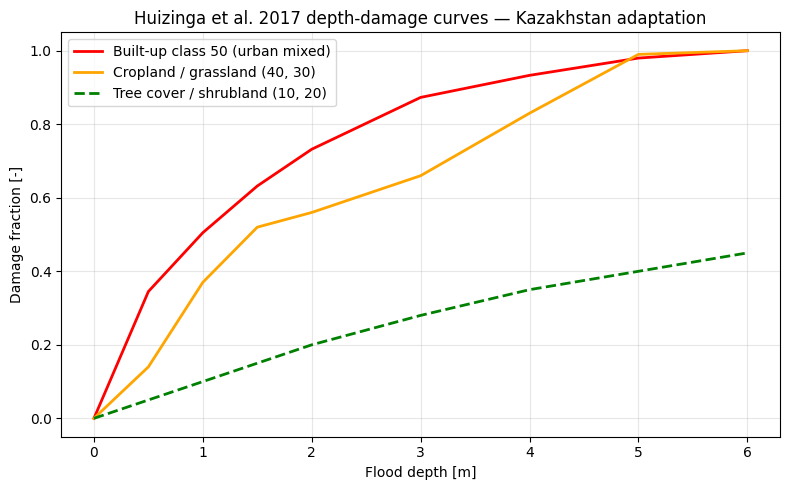

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, urban_mixed,  label='Built-up class 50 (urban mixed)', lw=2, color='red')
ax.plot(depths, agriculture,  label='Cropland / grassland (40, 30)',   lw=2, color='orange')
ax.plot(depths, forest_curve, label='Tree cover / shrubland (10, 20)', lw=2, color='green', linestyle='--')
ax.set_xlabel('Flood depth [m]')
ax.set_ylabel('Damage fraction [-]')
ax.set_title('Huizinga et al. 2017 depth-damage curves — Kazakhstan adaptation')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(plot_dir / f'DamageCurves_{region_name}.png', dpi=150)
plt.show()

## 5 — Resample flood maps to land cover grid

Flood maps (~90m) resampled onto the ESA WC grid (~100m) using bilinear interpolation.

In [15]:
tif_dir = data_dir / 'floodmaps_resampled'
tif_dir.mkdir(exist_ok=True)

floodmaps_resampled = None

for ii, rp in enumerate(rps):
    print(f'  Resampling {rp}...')
    da = floodmaps[rp].squeeze()
    da.rio.write_crs('EPSG:4326', inplace=True)
    da_res = da.rio.reproject_match(esa_wc_local, resampling=Resampling.bilinear)
    da_res.name = rp
    da_res.rio.to_raster(tif_dir / f'floodmap_resampled_{region_name}_{rp}.tif')
    ds = da_res.to_dataset()
    floodmaps_resampled = ds if ii == 0 else floodmaps_resampled.merge(ds)

print(f'Resampled resolution: {floodmaps_resampled.rio.resolution()}')

  Resampling RP10...
  Resampling RP50...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 else floodmaps_resampled.merge(ds)
C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 els

  Resampling RP100...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 else floodmaps_resampled.merge(ds)
C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 els

  Resampling RP200...


C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 else floodmaps_resampled.merge(ds)
C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 els

  Resampling RP500...
Resampled resolution: (0.0008996414634157902, -0.0008983164328656675)


C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 else floodmaps_resampled.merge(ds)
C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\886181621.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  floodmaps_resampled = ds if ii == 0 els

## 6 — Calculate economic damages

**Substitution:** DamageScanner (requires osgeo/GDAL) → direct numpy raster calculation.
Method is identical: for each pixel, interpolate the damage curve at the flood depth,
multiply by the maximum damage value for that land cover class.

In [16]:
def calc_damage_map(flood_arr, lc_arr, class_params, depths):
    damage_map = np.zeros_like(flood_arr, dtype=np.float64)
    valid      = ~np.isnan(flood_arr) & (flood_arr > 0)

    for cls, (curve, maxdam) in class_params.items():
        mask = valid & (lc_arr == cls)
        if not mask.any():
            continue
        frac = np.interp(flood_arr[mask], depths, curve)
        damage_map[mask] = frac * maxdam 

    return damage_map

In [17]:
with rasterio.open(landcover_path) as src:
    lc_arr      = src.read(1).astype(float)
    lc_meta     = src.meta.copy()
    lc_transform= src.transform
    lc_crs      = src.crs

loss_rows = []

for rp in rps:
    flood_path = tif_dir / f'floodmap_resampled_{region_name}_{rp}.tif'

    with rasterio.open(flood_path) as src:
        flood_arr = src.read(1).astype(float)
        flood_arr[flood_arr <= 0] = np.nan

    dmg_map = calc_damage_map(flood_arr, lc_arr, CLASS_PARAMS, depths)

    dmg_path = results_dir / f'flood_{region_name}_{rp}_damagemap.tif'
    meta = lc_meta.copy()
    meta.update(dtype='float64', count=1, nodata=0)
    with rasterio.open(dmg_path, 'w', **meta) as dst:
        dst.write(dmg_map, 1)

    total_usd = dmg_map.sum()
    print(f'  {rp}: total damage = ${total_usd/1e6:.2f}M USD')

    for cls in CLASS_PARAMS:
        mask     = (lc_arr == cls)
        cls_dmg  = dmg_map[mask].sum()
        loss_rows.append({'rp': rp, 'class': cls, 'damage_usd': cls_dmg})

  RP10: total damage = $1.61M USD
  RP50: total damage = $1.95M USD
  RP100: total damage = $2.09M USD
  RP200: total damage = $2.23M USD
  RP500: total damage = $2.42M USD


In [18]:
loss_df = pd.DataFrame(loss_rows)
loss_pivot = loss_df.pivot(index='class', columns='rp', values='damage_usd') / 1e6
loss_pivot.insert(0, 'Land cover', [ESA_WC_LABELS.get(c, ('Unknown',))[0] for c in loss_pivot.index])
loss_pivot.sort_values(by=rps[-1], ascending=False, inplace=True)
print('\nDamages by land cover class [million USD]:')
print(loss_pivot.to_string())
loss_pivot.to_csv(results_dir / f'damage_by_class_{region_name}.csv')


Damages by land cover class [million USD]:
rp             Land cover          RP10         RP100         RP200          RP50         RP500
class                                                                                          
50               Built-up  1.363031e+00  1.797404e+00  1.919340e+00  1.672524e+00  2.096012e+00
30              Grassland  1.193193e-01  1.437811e-01  1.497170e-01  1.373578e-01  1.571307e-01
90     Herbaceous wetland  5.895921e-02  6.494266e-02  6.638333e-02  6.332913e-02  6.808678e-02
40               Cropland  3.986928e-02  5.240239e-02  5.563643e-02  4.899916e-02  5.982865e-02
10             Tree cover  2.789813e-02  3.421272e-02  3.565674e-02  3.259939e-02  3.742132e-02
20              Shrubland  3.456829e-07  2.306993e-07  2.484463e-07  2.916402e-07  2.876797e-07
95              Mangroves  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00


## 7 — Plot damage maps

In [19]:
damagemap_all = None

for ii, rp in enumerate(rps):
    dm = rxr.open_rasterio(
        results_dir / f'flood_{region_name}_{rp}_damagemap.tif'
    ).squeeze()
    dm = dm.where(dm > 0) / 1e6
    dm.load()
    dm.name = 'damages'
    dm = dm.assign_coords(return_period=rp).expand_dims('return_period')
    damagemap_all = dm.to_dataset() if damagemap_all is None else damagemap_all.merge(dm.to_dataset())

C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\3372277630.py:11: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'return_period' ('return_period',) The recommendation is to set join explicitly for this case.
  damagemap_all = dm.to_dataset() if damagemap_all is None else damagemap_all.merge(dm.to_dataset())
C:\Users\dauzo\AppData\Local\Temp\ipykernel_32556\3372277630.py:11: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dam

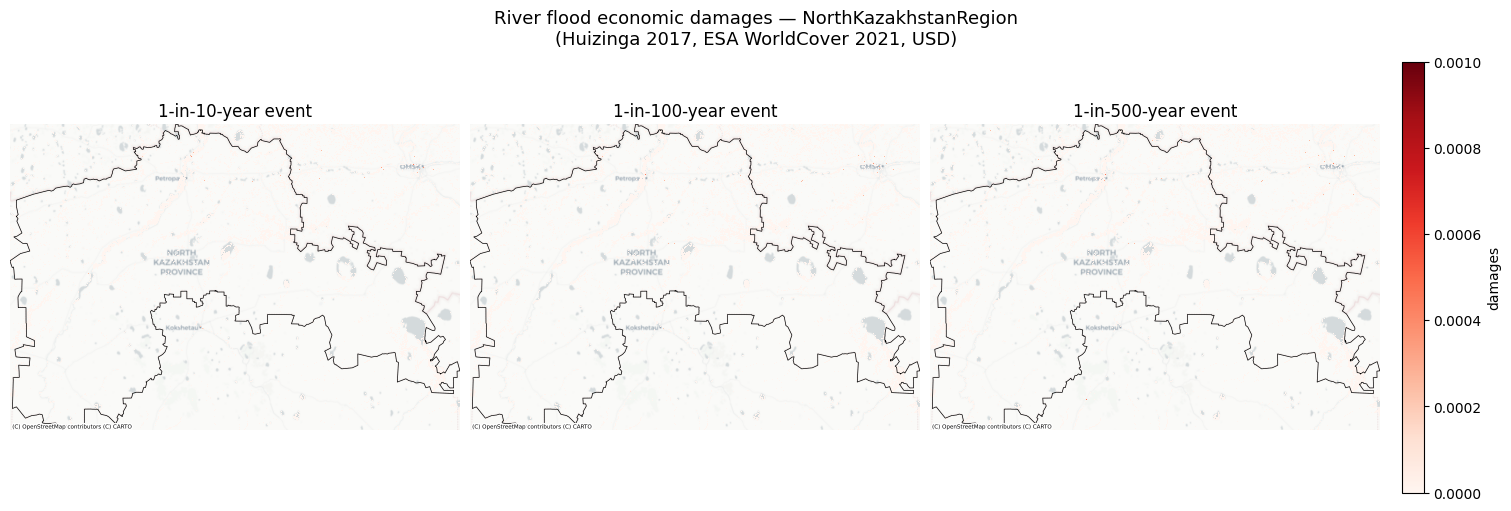

In [20]:
rps_sel  = ['RP10', 'RP100', 'RP500']
vmax_dmg = float(np.nanmax(damagemap_all.sel(return_period='RP500')['damages'].values))

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharex=True, sharey=True)

for ii, rp in enumerate(rps_sel):
    dm_plot = damagemap_all.sel(return_period=rp)['damages'].isel(
        x=slice(None,None,3), y=slice(None,None,3)
    )
    last = (ii == len(rps_sel) - 1)
    _ckw = {'label': 'Damage [million USD]'} if last else {}
    dm_plot.plot(
        ax=axs[ii], cmap='Reds',
        vmin=0, vmax=max(vmax_dmg, 0.001),
        add_colorbar=last, **_ckw,
    )
    region_gdf.boundary.plot(ax=axs[ii], color='black', linewidth=0.5)
    ctx.add_basemap(axs[ii], crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
    axs[ii].set_title(f'1-in-{rp[2:]}-year event')
    axs[ii].set_axis_off()

fig.suptitle(
    f'River flood economic damages — {region_name}\n'
    f'(Huizinga 2017, ESA WorldCover 2021, USD)',
    fontsize=13,
)
fig.savefig(plot_dir / f'DamageMap_overview_{region_name}.png', dpi=150)
plt.show()

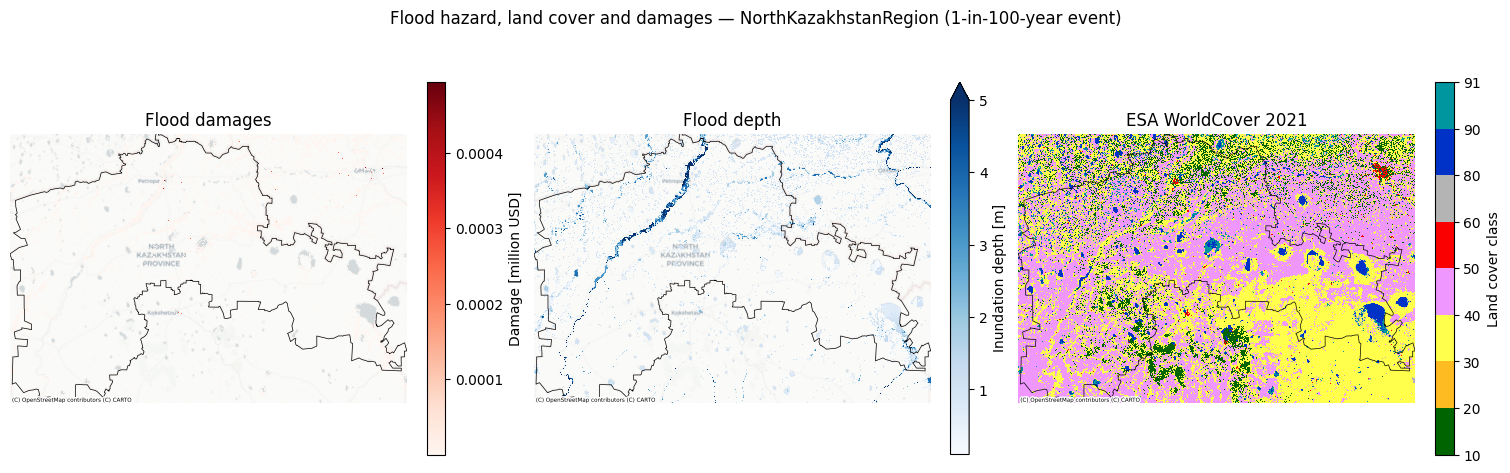

In [21]:
rp_detail = 'RP100'

dm_detail = rxr.open_rasterio(
    results_dir / f'flood_{region_name}_{rp_detail}_damagemap.tif'
).squeeze()
dm_detail = dm_detail.where(dm_detail > 0) / 1e6

fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True, sharex=True, sharey=True)

dm_detail.isel(x=slice(None,None,3), y=slice(None,None,3)).plot(
    ax=axs[0], cmap='Reds',
    cbar_kwargs={'label': 'Damage [million USD]', 'shrink': 0.8},
)
axs[0].set_title('Flood damages')

floodmaps_resampled[rp_detail].isel(x=slice(None,None,3), y=slice(None,None,3)).plot(
    ax=axs[1], cmap='Blues', vmax=5,
    cbar_kwargs={'label': 'Inundation depth [m]', 'shrink': 0.8},
)
axs[1].set_title('Flood depth')

esa_wc_local.isel(x=slice(None,None,3), y=slice(None,None,3)).plot(
    ax=axs[2], cmap=cmap_lc, norm=norm_lc,
    cbar_kwargs={'label': 'Land cover class', 'shrink': 0.8},
)
axs[2].set_title('ESA WorldCover 2021')

for ax in axs:
    region_gdf.boundary.plot(ax=ax, color='black', linewidth=0.5)
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution_size=4)
    ax.set_axis_off()

fig.suptitle(
    f'Flood hazard, land cover and damages — {region_name} (1-in-{rp_detail[2:]}-year event)',
    fontsize=12,
)
fig.savefig(plot_dir / f'DetailMap_{region_name}_{rp_detail}.png', dpi=150)
plt.show()

## Conclusions

This risk workflow produced economic damage estimates for river flooding in
Kazakhstan (North Kazakhstan Region) by combining:

- **Hazard**: CEMS-GLOFAS flood depth maps at ~90m resolution (present-day scenario)
- **Exposure**: ESA WorldCover 2021 at 100m (class 50 = built-up, class 40 = cropland
  are the primary damage contributors)
- **Vulnerability**: Huizinga et al. 2017 global depth-damage curves, Central Asia
  maximum damage values in USD/m²

**Known limitations:**
- Pixel area approximated as 100m × 100m in EPSG:4326 — actual area at 45°N is
  ~30% smaller, so absolute damage totals are slightly overestimated.
- ESA WC class 50 (built-up) does not distinguish residential from industrial
  from commercial at sub-100m scale.
- Huizinga max damage values are regional averages; local asset values in North Kazakhstan Region may differ, especially for infrastructure.
- GLOFAS does not model flood protection infrastructure (levees, reservoirs)
  present on rivers.